In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
users = pd.read_csv("/content/users.csv")
flights = pd.read_csv("/content/flights.csv")
hotels = pd.read_csv("/content/hotels.csv")

print("Users shape   :", users.shape)
print("Flights shape :", flights.shape)
print("Hotels shape  :", hotels.shape)

Users shape   : (1340, 5)
Flights shape : (233957, 10)
Hotels shape  : (40552, 8)


In [ ]:
# Cell 3 — Hotel Data Inspection

print("Hotel columns:")
print(hotels.columns.tolist())

print("\nFirst 10 hotel records:")
display(hotels.head(10))

print("\nData types:")
print(hotels.dtypes)

print("\nMissing values:")
print(hotels.isnull().sum())

print("\nUnique hotels:", hotels["name"].nunique())
print("Unique locations:", hotels["place"].nunique())
print("Unique users:", hotels["userCode"].nunique())
print("Unique travel codes:", hotels["travelCode"].nunique())

Hotel columns:
['travelCode', 'userCode', 'name', 'place', 'days', 'price', 'total', 'date']

First 10 hotel records:


,travelCode,userCode,name,place,days,price,total,date
0,0,0,Hotel A,Florianopolis (SC),4,313.02,1252.08,09/26/2019
1,2,0,Hotel K,Salvador (BH),2,263.41,526.82,10/10/2019
2,7,0,Hotel K,Salvador (BH),3,263.41,790.23,11/14/2019
3,11,0,Hotel K,Salvador (BH),4,263.41,1053.64,12/12/2019
4,13,0,Hotel A,Florianopolis (SC),1,313.02,313.02,12/26/2019
5,15,0,Hotel BD,Natal (RN),2,242.88,485.76,01/09/2020
6,22,0,Hotel Z,Aracaju (SE),2,208.04,416.08,02/27/2020
7,29,0,Hotel AU,Recife (PE),4,312.83,1251.32,04/16/2020
8,32,0,Hotel AF,Sao Paulo (SP),2,139.10,278.20,05/07/2020
9,33,0,Hotel K,Salvador (BH),4,263.41,1053.64,05/14/2020



Data types:
travelCode      int64
userCode        int64
name           object
place          object
days            int64
price         float64
total         float64
date           object
dtype: object

Missing values:
travelCode    0
userCode      0
name          0
place         0
days          0
price         0
total         0
date          0
dtype: int64

Unique hotels: 9
Unique locations: 9
Unique users: 1310
Unique travel codes: 40552


In [ ]:

hotel_location_mapping = (
    hotels.groupby("name")["place"]
    .nunique()
    .sort_values(ascending=False)
)

print("Number of locations per hotel:")
display(hotel_location_mapping)

print("\nHotel → Location mapping:")
display(
    hotels[["name", "place"]]
    .drop_duplicates()
    .sort_values(["name", "place"])
    .reset_index(drop=True)
)

Number of locations per hotel:


,place
name,
Hotel A,1
Hotel AF,1
Hotel AU,1
Hotel BD,1
Hotel BP,1
Hotel BW,1
Hotel CB,1
Hotel K,1
Hotel Z,1



Hotel → Location mapping:


,name,place
0,Hotel A,Florianopolis (SC)
1,Hotel AF,Sao Paulo (SP)
2,Hotel AU,Recife (PE)
3,Hotel BD,Natal (RN)
4,Hotel BP,Brasilia (DF)
5,Hotel BW,Campo Grande (MS)
6,Hotel CB,Rio de Janeiro (RJ)
7,Hotel K,Salvador (BH)
8,Hotel Z,Aracaju (SE)


In [ ]:

# --------------------------------------------------
# Cell 5 — User-Hotel Interaction Matrix
# --------------------------------------------------

# Count how many times each user booked each hotel
user_hotel_interactions = (
    hotels
    .groupby(["userCode", "name"])
    .size()
    .reset_index(name="booking_count")
)

print("User-Hotel interaction records:")
print(user_hotel_interactions.shape)

print("\nFirst 10 interaction records:")
display(
    user_hotel_interactions.head(10)
)


# Create User × Hotel matrix
user_hotel_matrix = (
    user_hotel_interactions
    .pivot_table(
        index="userCode",
        columns="name",
        values="booking_count",
        fill_value=0
    )
)

print("\nUser-Hotel matrix shape:")
print(user_hotel_matrix.shape)

print("\nUser-Hotel matrix:")
display(user_hotel_matrix.head(10))

User-Hotel interaction records:
(9724, 3)

First 10 interaction records:


,userCode,name,booking_count
0,0,Hotel A,3
1,0,Hotel AF,4
2,0,Hotel AU,2
3,0,Hotel BD,4
4,0,Hotel BP,1
5,0,Hotel BW,2
6,0,Hotel CB,1
7,0,Hotel K,7
8,0,Hotel Z,3
9,1,Hotel AF,1



User-Hotel matrix shape:
(1310, 9)

User-Hotel matrix:


name,Hotel A,Hotel AF,Hotel AU,Hotel BD,Hotel BP,Hotel BW,Hotel CB,Hotel K,Hotel Z
userCode,,,,,,,,,
0,3.0,4.0,2.0,4.0,1.0,2.0,1.0,7.0,3.0
1,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,6.0,2.0,3.0,2.0,2.0,7.0,3.0,5.0,6.0
3,10.0,6.0,7.0,11.0,2.0,9.0,7.0,6.0,2.0
4,7.0,6.0,7.0,5.0,3.0,6.0,11.0,7.0,4.0
5,1.0,3.0,0.0,1.0,0.0,1.0,1.0,5.0,1.0
6,4.0,5.0,1.0,3.0,3.0,1.0,3.0,3.0,0.0
7,0.0,1.0,2.0,3.0,1.0,5.0,1.0,0.0,1.0
8,6.0,4.0,8.0,12.0,4.0,6.0,4.0,3.0,5.0


Hotel popularity (total bookings):


,total_bookings
name,
Hotel K,5094
Hotel CB,5029
Hotel BD,4829
Hotel AF,4828
Hotel AU,4467
Hotel BP,4437
Hotel BW,4333
Hotel Z,4205
Hotel A,3330



Hotel popularity percentage:


,booking_percentage
name,
Hotel K,12.56
Hotel CB,12.40
Hotel BD,11.91
Hotel AF,11.91
Hotel AU,11.02
Hotel BP,10.94
Hotel BW,10.69
Hotel Z,10.37
Hotel A,8.21



Unique users per hotel:


,unique_users
name,
Hotel CB,1166
Hotel K,1158
Hotel BD,1152
Hotel AF,1151
Hotel AU,1130
Hotel BP,1120
Hotel Z,1106
Hotel BW,992
Hotel A,749



Interaction statistics:
Total possible interactions : 11790
Actual user-hotel interactions: 9724
Sparsity                    : 17.52%


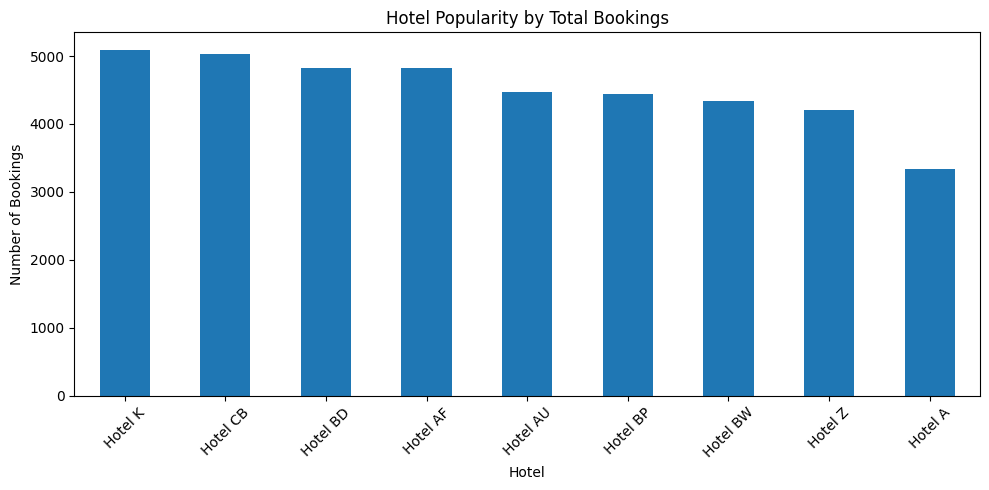

In [ ]:
# Cell 6 — Hotel Popularity & Interaction Sparsity

# Total bookings for each hotel
hotel_popularity = (
    hotels.groupby("name")
    .size()
    .sort_values(ascending=False)
)

print("Hotel popularity (total bookings):")
display(hotel_popularity.to_frame("total_bookings"))

# Percentage of all bookings
hotel_popularity_pct = (
    hotel_popularity / hotel_popularity.sum() * 100
).round(2)

print("\nHotel popularity percentage:")
display(hotel_popularity_pct.to_frame("booking_percentage"))

# Number of unique users who booked each hotel
unique_users_per_hotel = (
    hotels.groupby("name")["userCode"]
    .nunique()
    .sort_values(ascending=False)
)

print("\nUnique users per hotel:")
display(unique_users_per_hotel.to_frame("unique_users"))

# Interaction sparsity
total_possible_interactions = (
    user_hotel_matrix.shape[0] * user_hotel_matrix.shape[1]
)

actual_interactions = (
    user_hotel_matrix > 0
).sum().sum()

sparsity = (
    1 - actual_interactions / total_possible_interactions
) * 100

print("\nInteraction statistics:")
print("Total possible interactions :", total_possible_interactions)
print("Actual user-hotel interactions:", actual_interactions)
print(f"Sparsity                    : {sparsity:.2f}%")

# Visualize hotel popularity
plt.figure(figsize=(10, 5))
hotel_popularity.plot(kind="bar")
plt.title("Hotel Popularity by Total Bookings")
plt.xlabel("Hotel")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Cell 7 — Popularity-Based Recommendation Baseline

# Rank hotels by total booking count
popular_hotels = (
    hotels.groupby("name")
    .agg(
        total_bookings=("name", "size"),
        unique_users=("userCode", "nunique"),
        average_price=("price", "mean"),
        average_stay_days=("days", "mean")
    )
    .sort_values("total_bookings", ascending=False)
)

print("Popularity-based hotel ranking:")
display(popular_hotels)

# Function to recommend the most popular hotels
def popularity_recommend(user_code=None, top_n=5):
    """
    Recommend the most popular hotels.

    user_code is accepted for compatibility with later
    personalized recommenders, but is not used here.
    """
    return popular_hotels.head(top_n).reset_index()["name"].tolist()


# Test the baseline
print("\nExample popularity recommendations:")
print(popularity_recommend(user_code=0, top_n=5))

Popularity-based hotel ranking:


,total_bookings,unique_users,average_price,average_stay_days
name,,,,
Hotel K,5094,1158,263.41,2.516490
Hotel CB,5029,1166,165.99,2.485981
Hotel BD,4829,1152,242.88,2.499068
Hotel AF,4828,1151,139.10,2.511599
Hotel AU,4467,1130,312.83,2.520931
Hotel BP,4437,1120,247.62,2.486365
Hotel BW,4333,992,60.39,2.495500
Hotel Z,4205,1106,208.04,2.491558
Hotel A,3330,749,313.02,2.483183



Example popularity recommendations:
['Hotel K', 'Hotel CB', 'Hotel BD', 'Hotel AF', 'Hotel AU']


In [ ]:
# Cell 8 — Train/Test Split for Hotel Recommendation

# Work with users who have at least 2 different hotels booked.
# This allows us to hide one hotel and keep the remaining history
# available for generating personalized recommendations.

user_hotel_binary = (user_hotel_matrix > 0).astype(int)

eligible_users = user_hotel_binary.sum(axis=1)
eligible_users = eligible_users[eligible_users >= 2].index

print("Total users in interaction matrix :", len(user_hotel_matrix))
print("Users eligible for evaluation      :", len(eligible_users))

# Create train matrix by hiding one hotel for each eligible user.
# We use the last hotel alphabetically only as a deterministic
# holdout for this baseline evaluation.
train_matrix = user_hotel_binary.copy()
test_items = {}

for user in eligible_users:
    booked_hotels = user_hotel_binary.loc[user]
    booked_hotels = booked_hotels[booked_hotels > 0].index.tolist()

    # Deterministic holdout
    test_hotel = sorted(booked_hotels)[-1]

    train_matrix.loc[user, test_hotel] = 0
    test_items[user] = test_hotel

print("\nTrain matrix shape:", train_matrix.shape)
print("Number of test users:", len(test_items))

print("\nExample held-out hotels:")
for user, hotel in list(test_items.items())[:10]:
    print(f"User {user} -> {hotel}")

# Verify that every test user still has at least one hotel
remaining_interactions = train_matrix.loc[list(test_items.keys())].sum(axis=1)

print("\nMinimum remaining hotels for test users:",
      remaining_interactions.min())

print("Train/test preparation completed successfully.")

Total users in interaction matrix : 1310
Users eligible for evaluation      : 1285

Train matrix shape: (1310, 9)
Number of test users: 1285

Example held-out hotels:
User 0 -> Hotel Z
User 1 -> Hotel BP
User 2 -> Hotel Z
User 3 -> Hotel Z
User 4 -> Hotel Z
User 5 -> Hotel Z
User 6 -> Hotel K
User 7 -> Hotel Z
User 8 -> Hotel Z
User 9 -> Hotel Z

Minimum remaining hotels for test users: 1
Train/test preparation completed successfully.


In [ ]:
# Cell 9 — Evaluate Popularity Baseline

def evaluate_popularity_baseline(test_items, popular_hotels, k_values=[1, 3, 5]):
    results = []

    ranked_hotels = popular_hotels.index.tolist()

    for k in k_values:
        hits = 0

        recommendations = ranked_hotels[:k]

        for user, actual_hotel in test_items.items():
            if actual_hotel in recommendations:
                hits += 1

        hit_rate = hits / len(test_items)

        results.append({
            "K": k,
            "Hits": hits,
            "Total Test Users": len(test_items),
            "Hit Rate": round(hit_rate, 4)
        })

    return pd.DataFrame(results)


# Evaluate baseline
popularity_results = evaluate_popularity_baseline(
    test_items,
    popular_hotels,
    k_values=[1, 3, 5]
)

print("Popularity Baseline Evaluation:")
display(popularity_results)

print("\nInterpretation:")
print("Hit Rate@K = percentage of users whose hidden hotel")
print("appears in the top-K recommendations.")

Popularity Baseline Evaluation:


,K,Hits,Total Test Users,Hit Rate
0,1,132,1285,0.1027
1,3,163,1285,0.1268
2,5,166,1285,0.1292



Interpretation:
Hit Rate@K = percentage of users whose hidden hotel
appears in the top-K recommendations.


In [ ]:
# Cell 10 — User-Based Collaborative Filtering

# Calculate cosine similarity between users
user_similarity = cosine_similarity(train_matrix)

# Convert to DataFrame for easier interpretation
user_similarity_df = pd.DataFrame(
    user_similarity,
    index=train_matrix.index,
    columns=train_matrix.index
)

print("User similarity matrix shape:")
print(user_similarity_df.shape)

# Inspect similarity for User 0
user_id = 0

similar_users = (
    user_similarity_df.loc[user_id]
    .drop(user_id)
    .sort_values(ascending=False)
    .head(10)
)

print(f"\nTop 10 users most similar to User {user_id}:")
display(similar_users.to_frame("similarity"))

print("\nSimilarity statistics:")
print("Minimum similarity:", user_similarity_df.values.min())
print("Maximum similarity:", user_similarity_df.values.max())
print("Mean similarity   :", user_similarity_df.values.mean())

User similarity matrix shape:
(1310, 1310)

Top 10 users most similar to User 0:


,similarity
userCode,
18,1.0
16,1.0
15,1.0
13,1.0
12,1.0
11,1.0
9,1.0
46,1.0
43,1.0



Similarity statistics:
Minimum similarity: 0.0
Maximum similarity: 1.0000000000000002
Mean similarity   : 0.7926092519206991


In [ ]:
# Cell 11 — User-Based Collaborative Filtering Recommender

def collaborative_recommend(user_id, train_matrix, user_similarity_df, top_n=5, n_neighbors=20):
    """
    Generate personalized hotel recommendations using
    similarity-weighted preferences of neighboring users.
    """

    # Similar users excluding the target user
    similar_users = (
        user_similarity_df.loc[user_id]
        .drop(user_id)
        .sort_values(ascending=False)
        .head(n_neighbors)
    )

    # Get hotel interactions of similar users
    neighbor_matrix = train_matrix.loc[similar_users.index]

    # Weight each neighbor's hotel interactions by similarity
    weighted_scores = neighbor_matrix.T.dot(similar_users)

    # Normalize by total similarity
    similarity_sum = similar_users.sum()

    if similarity_sum > 0:
        weighted_scores = weighted_scores / similarity_sum

    # Remove hotels already booked by the target user
    already_booked = train_matrix.loc[user_id]
    already_booked = already_booked[already_booked > 0].index

    weighted_scores = weighted_scores.drop(
        already_booked,
        errors="ignore"
    )

    # Rank hotels
    recommendations = (
        weighted_scores
        .sort_values(ascending=False)
        .head(top_n)
    )

    return recommendations


# Test recommendations for a few users
test_users = list(test_items.keys())[:5]

for user_id in test_users:
    print(f"\nUser {user_id}")
    print("Already booked:")
    print(
        train_matrix.loc[user_id]
        [train_matrix.loc[user_id] > 0]
        .index.tolist()
    )

    print("Recommended hotels:")
    display(
        collaborative_recommend(
            user_id,
            train_matrix,
            user_similarity_df,
            top_n=5,
            n_neighbors=20
        ).to_frame("recommendation_score")
    )


User 0
Already booked:
['Hotel A', 'Hotel AF', 'Hotel AU', 'Hotel BD', 'Hotel BP', 'Hotel BW', 'Hotel CB', 'Hotel K']
Recommended hotels:


,recommendation_score
name,
Hotel Z,0.0



User 1
Already booked:
['Hotel AF']
Recommended hotels:


,recommendation_score
name,
Hotel BD,0.262015
Hotel AU,0.087338
Hotel CB,0.087338
Hotel A,0.043669
Hotel BP,0.043669



User 2
Already booked:
['Hotel A', 'Hotel AF', 'Hotel AU', 'Hotel BD', 'Hotel BP', 'Hotel BW', 'Hotel CB', 'Hotel K']
Recommended hotels:


,recommendation_score
name,
Hotel Z,0.0



User 3
Already booked:
['Hotel A', 'Hotel AF', 'Hotel AU', 'Hotel BD', 'Hotel BP', 'Hotel BW', 'Hotel CB', 'Hotel K']
Recommended hotels:


,recommendation_score
name,
Hotel Z,0.0



User 4
Already booked:
['Hotel A', 'Hotel AF', 'Hotel AU', 'Hotel BD', 'Hotel BP', 'Hotel BW', 'Hotel CB', 'Hotel K']
Recommended hotels:


,recommendation_score
name,
Hotel Z,0.0


In [ ]:
# Cell 12 — Frequency-Weighted Collaborative Filtering

# Use booking counts instead of binary interactions
frequency_matrix = user_hotel_matrix.copy()

# Create similarity using booking frequency
frequency_similarity = cosine_similarity(frequency_matrix)

frequency_similarity_df = pd.DataFrame(
    frequency_similarity,
    index=frequency_matrix.index,
    columns=frequency_matrix.index
)

print("Frequency-based similarity matrix shape:")
print(frequency_similarity_df.shape)

print("\nFrequency similarity statistics:")
print("Minimum similarity:", frequency_similarity_df.values.min())
print("Maximum similarity:", frequency_similarity_df.values.max())
print("Mean similarity   :", frequency_similarity_df.values.mean())


def frequency_collaborative_recommend(
    user_id,
    frequency_matrix,
    similarity_df,
    top_n=5,
    n_neighbors=20
):
    """
    Generate hotel recommendations using:
    - booking frequency
    - cosine similarity between users
    - similarity-weighted hotel preferences
    """

    # Find nearest neighbors
    similar_users = (
        similarity_df.loc[user_id]
        .drop(user_id)
        .sort_values(ascending=False)
        .head(n_neighbors)
    )

    # Neighbor booking-frequency matrix
    neighbor_matrix = frequency_matrix.loc[similar_users.index]

    # Weighted preference score
    weighted_scores = neighbor_matrix.T.dot(similar_users)

    # Normalize scores
    similarity_sum = similar_users.sum()

    if similarity_sum > 0:
        weighted_scores = weighted_scores / similarity_sum

    # Remove hotels already booked by user
    already_booked = frequency_matrix.loc[user_id]
    already_booked = already_booked[already_booked > 0].index

    weighted_scores = weighted_scores.drop(
        already_booked,
        errors="ignore"
    )

    # Rank recommendations
    recommendations = (
        weighted_scores
        .sort_values(ascending=False)
        .head(top_n)
    )

    return recommendations


# Test on the same users
for user_id in test_users:

    print(f"\n{'='*50}")
    print(f"User {user_id}")

    print("\nAlready booked:")
    print(
        frequency_matrix.loc[user_id]
        [frequency_matrix.loc[user_id] > 0]
        .sort_values(ascending=False)
        .to_dict()
    )

    print("\nFrequency-weighted recommendations:")

    display(
        frequency_collaborative_recommend(
            user_id,
            frequency_matrix,
            frequency_similarity_df,
            top_n=5,
            n_neighbors=20
        ).to_frame("recommendation_score")
    )

Frequency-based similarity matrix shape:
(1310, 1310)

Frequency similarity statistics:
Minimum similarity: 0.0
Maximum similarity: 1.0000000000000004
Mean similarity   : 0.6867514168353291

User 0

Already booked:
{'Hotel K': 7.0, 'Hotel BD': 4.0, 'Hotel AF': 4.0, 'Hotel A': 3.0, 'Hotel Z': 3.0, 'Hotel BW': 2.0, 'Hotel AU': 2.0, 'Hotel BP': 1.0, 'Hotel CB': 1.0}

Frequency-weighted recommendations:


,recommendation_score
name,



User 1

Already booked:
{'Hotel AF': 1.0, 'Hotel BP': 1.0}

Frequency-weighted recommendations:


,recommendation_score
name,
Hotel AU,1.891117
Hotel Z,1.698538
Hotel BD,1.596560
Hotel CB,1.470649
Hotel K,1.457616



User 2

Already booked:
{'Hotel BW': 7.0, 'Hotel A': 6.0, 'Hotel Z': 6.0, 'Hotel K': 5.0, 'Hotel AU': 3.0, 'Hotel CB': 3.0, 'Hotel BP': 2.0, 'Hotel AF': 2.0, 'Hotel BD': 2.0}

Frequency-weighted recommendations:


,recommendation_score
name,



User 3

Already booked:
{'Hotel BD': 11.0, 'Hotel A': 10.0, 'Hotel BW': 9.0, 'Hotel CB': 7.0, 'Hotel AU': 7.0, 'Hotel K': 6.0, 'Hotel AF': 6.0, 'Hotel BP': 2.0, 'Hotel Z': 2.0}

Frequency-weighted recommendations:


,recommendation_score
name,



User 4

Already booked:
{'Hotel CB': 11.0, 'Hotel A': 7.0, 'Hotel AU': 7.0, 'Hotel K': 7.0, 'Hotel AF': 6.0, 'Hotel BW': 6.0, 'Hotel BD': 5.0, 'Hotel Z': 4.0, 'Hotel BP': 3.0}

Frequency-weighted recommendations:


,recommendation_score
name,


In [ ]:
# Cell 13 — Create Proper Frequency-Based Train Matrix

# Start with the original booking-frequency matrix
frequency_train_matrix = frequency_matrix.copy()

# Remove the held-out hotel for every test user
for user_id, test_hotel in test_items.items():
    frequency_train_matrix.loc[user_id, test_hotel] = 0

print("Original frequency matrix shape:")
print(frequency_matrix.shape)

print("\nFrequency training matrix shape:")
print(frequency_train_matrix.shape)

# Verify a few users
print("\nVerification of held-out hotels:")

for user_id, test_hotel in list(test_items.items())[:10]:
    original_value = frequency_matrix.loc[user_id, test_hotel]
    train_value = frequency_train_matrix.loc[user_id, test_hotel]

    print(
        f"User {user_id} | "
        f"Hidden: {test_hotel} | "
        f"Original count: {original_value} | "
        f"Train count: {train_value}"
    )

print("\nTrain matrix successfully created without held-out interactions.")

Original frequency matrix shape:
(1310, 9)

Frequency training matrix shape:
(1310, 9)

Verification of held-out hotels:
User 0 | Hidden: Hotel Z | Original count: 3.0 | Train count: 0.0
User 1 | Hidden: Hotel BP | Original count: 1.0 | Train count: 0.0
User 2 | Hidden: Hotel Z | Original count: 6.0 | Train count: 0.0
User 3 | Hidden: Hotel Z | Original count: 2.0 | Train count: 0.0
User 4 | Hidden: Hotel Z | Original count: 4.0 | Train count: 0.0
User 5 | Hidden: Hotel Z | Original count: 1.0 | Train count: 0.0
User 6 | Hidden: Hotel K | Original count: 3.0 | Train count: 0.0
User 7 | Hidden: Hotel Z | Original count: 1.0 | Train count: 0.0
User 8 | Hidden: Hotel Z | Original count: 5.0 | Train count: 0.0
User 9 | Hidden: Hotel Z | Original count: 2.0 | Train count: 0.0

Train matrix successfully created without held-out interactions.


In [ ]:
# Cell 14 — Frequency-Weighted Collaborative Filtering Recommender

# Calculate user similarity using ONLY the training data
frequency_train_similarity = cosine_similarity(frequency_train_matrix)

frequency_train_similarity_df = pd.DataFrame(
    frequency_train_similarity,
    index=frequency_train_matrix.index,
    columns=frequency_train_matrix.index
)


def frequency_collaborative_recommend(
    user_id,
    train_matrix,
    similarity_df,
    top_n=5,
    n_neighbors=20
):
    """
    Frequency-weighted user-based collaborative filtering.

    Uses:
    - booking frequency
    - cosine similarity
    - similarity-weighted neighbor preferences

    The user's already-seen hotels are excluded.
    """

    # Find most similar users
    similar_users = (
        similarity_df.loc[user_id]
        .drop(user_id)
        .sort_values(ascending=False)
        .head(n_neighbors)
    )

    # Get booking frequencies of similar users
    neighbor_matrix = train_matrix.loc[similar_users.index]

    # Calculate weighted hotel preference scores
    weighted_scores = neighbor_matrix.T.dot(similar_users)

    # Normalize by similarity
    similarity_sum = similar_users.sum()

    if similarity_sum > 0:
        weighted_scores = weighted_scores / similarity_sum

    # Remove hotels already booked in training data
    already_booked = train_matrix.loc[user_id]
    already_booked = already_booked[already_booked > 0].index

    weighted_scores = weighted_scores.drop(
        already_booked,
        errors="ignore"
    )

    # Return ranked recommendations
    return weighted_scores.sort_values(
        ascending=False
    ).head(top_n)


print("Frequency-weighted collaborative filtering model ready.")

print("\nTraining similarity matrix:")
print(frequency_train_similarity_df.shape)

# Test on first 5 evaluation users
for user_id in list(test_items.keys())[:5]:

    print(f"\n{'='*55}")
    print(f"User {user_id}")
    print(f"Actual hidden hotel: {test_items[user_id]}")

    print("\nHotels remaining in training history:")
    print(
        frequency_train_matrix.loc[user_id]
        [frequency_train_matrix.loc[user_id] > 0]
        .sort_values(ascending=False)
        .to_dict()
    )

    print("\nRecommended hotels:")

    recommendations = frequency_collaborative_recommend(
        user_id,
        frequency_train_matrix,
        frequency_train_similarity_df,
        top_n=5,
        n_neighbors=20
    )

    display(
        recommendations.to_frame("recommendation_score")
    )


Frequency-weighted collaborative filtering model ready.

Training similarity matrix:
(1310, 1310)

User 0
Actual hidden hotel: Hotel Z

Hotels remaining in training history:
{'Hotel K': 7.0, 'Hotel AF': 4.0, 'Hotel BD': 4.0, 'Hotel A': 3.0, 'Hotel AU': 2.0, 'Hotel BW': 2.0, 'Hotel BP': 1.0, 'Hotel CB': 1.0}

Recommended hotels:


,recommendation_score
name,
Hotel Z,0.0



User 1
Actual hidden hotel: Hotel BP

Hotels remaining in training history:
{'Hotel AF': 1.0}

Recommended hotels:


,recommendation_score
name,
Hotel BD,0.563845
Hotel AU,0.370951
Hotel BP,0.323596
Hotel CB,0.277181
Hotel BW,0.185958



User 2
Actual hidden hotel: Hotel Z

Hotels remaining in training history:
{'Hotel BW': 7.0, 'Hotel A': 6.0, 'Hotel K': 5.0, 'Hotel AU': 3.0, 'Hotel CB': 3.0, 'Hotel AF': 2.0, 'Hotel BD': 2.0, 'Hotel BP': 2.0}

Recommended hotels:


,recommendation_score
name,
Hotel Z,0.0



User 3
Actual hidden hotel: Hotel Z

Hotels remaining in training history:
{'Hotel BD': 11.0, 'Hotel A': 10.0, 'Hotel BW': 9.0, 'Hotel AU': 7.0, 'Hotel CB': 7.0, 'Hotel AF': 6.0, 'Hotel K': 6.0, 'Hotel BP': 2.0}

Recommended hotels:


,recommendation_score
name,
Hotel Z,0.0



User 4
Actual hidden hotel: Hotel Z

Hotels remaining in training history:
{'Hotel CB': 11.0, 'Hotel A': 7.0, 'Hotel K': 7.0, 'Hotel AU': 7.0, 'Hotel BW': 6.0, 'Hotel AF': 6.0, 'Hotel BD': 5.0, 'Hotel BP': 3.0}

Recommended hotels:


,recommendation_score
name,
Hotel Z,0.0


In [ ]:
# Cell 15 — Evaluate Frequency-Weighted Collaborative Filtering

def evaluate_collaborative_model(
    test_items,
    train_matrix,
    similarity_df,
    k_values=[1, 3, 5],
    n_neighbors=20
):
    results = []

    for k in k_values:

        hits = 0
        evaluated_users = 0

        for user_id, actual_hotel in test_items.items():

            recommendations = frequency_collaborative_recommend(
                user_id=user_id,
                train_matrix=train_matrix,
                similarity_df=similarity_df,
                top_n=k,
                n_neighbors=n_neighbors
            )

            # Skip users for whom no recommendation can be generated
            if len(recommendations) == 0:
                continue

            evaluated_users += 1

            if actual_hotel in recommendations.index:
                hits += 1

        hit_rate = (
            hits / evaluated_users
            if evaluated_users > 0
            else 0
        )

        results.append({
            "K": k,
            "Hits": hits,
            "Evaluated Users": evaluated_users,
            "Hit Rate": round(hit_rate, 4)
        })

    return pd.DataFrame(results)


# Evaluate collaborative filtering
collaborative_results = evaluate_collaborative_model(
    test_items=test_items,
    train_matrix=frequency_train_matrix,
    similarity_df=frequency_train_similarity_df,
    k_values=[1, 3, 5],
    n_neighbors=20
)

print("Collaborative Filtering Evaluation:")
display(collaborative_results)


# Compare with popularity baseline
comparison = popularity_results.merge(
    collaborative_results,
    on="K",
    suffixes=("_Popularity", "_Collaborative")
)

comparison["Improvement"] = (
    comparison["Hit Rate_Collaborative"]
    - comparison["Hit Rate_Popularity"]
)

comparison["Improvement_%"] = (
    comparison["Improvement"]
    / comparison["Hit Rate_Popularity"]
    * 100
).round(2)

print("\nPopularity vs Collaborative Filtering:")
display(comparison)

Collaborative Filtering Evaluation:


,K,Hits,Evaluated Users,Hit Rate
0,1,449,1285,0.3494
1,3,1137,1285,0.8848
2,5,1239,1285,0.9642



Popularity vs Collaborative Filtering:


,K,Hits_Popularity,Total Test Users,Hit Rate_Popularity,Hits_Collaborative,Evaluated Users,Hit Rate_Collaborative,Improvement,Improvement_%
0,1,132,1285,0.1027,449,1285,0.3494,0.2467,240.21
1,3,163,1285,0.1268,1137,1285,0.8848,0.7580,597.79
2,5,166,1285,0.1292,1239,1285,0.9642,0.8350,646.28


In [ ]:
# Cell 16 — Analyze User Hotel Coverage

# Number of unique hotels booked by each user
user_hotel_coverage = (
    (user_hotel_matrix > 0)
    .sum(axis=1)
)

coverage_distribution = (
    user_hotel_coverage
    .value_counts()
    .sort_index()
)

print("Number of hotels booked per user:")
display(
    coverage_distribution.to_frame("number_of_users")
)

print("\nCoverage statistics:")
print("Minimum hotels per user :", user_hotel_coverage.min())
print("Maximum hotels per user :", user_hotel_coverage.max())
print("Average hotels per user :", round(user_hotel_coverage.mean(), 2))
print("Median hotels per user  :", user_hotel_coverage.median())

print("\nPercentage of users by hotel coverage:")

coverage_percentage = (
    coverage_distribution
    / len(user_hotel_coverage)
    * 100
).round(2)

display(
    coverage_percentage.to_frame("percentage_of_users")
)

Number of hotels booked per user:


,number_of_users
1,25
2,28
3,33
4,43
5,58
6,76
7,126
8,545
9,376



Coverage statistics:
Minimum hotels per user : 1
Maximum hotels per user : 9
Average hotels per user : 7.42
Median hotels per user  : 8.0

Percentage of users by hotel coverage:


,percentage_of_users
1,1.91
2,2.14
3,2.52
4,3.28
5,4.43
6,5.80
7,9.62
8,41.60
9,28.70


In [ ]:
# Cell 17 — Create Hotel Feature Matrix

# Aggregate hotel-level characteristics
hotel_features = (
    hotels
    .groupby("name")
    .agg(
        place=("place", "first"),
        average_price=("price", "mean"),
        average_stay_days=("days", "mean"),
        total_bookings=("name", "size")
    )
    .reset_index()
)

print("Hotel feature table:")
display(hotel_features)

print("\nNumber of hotels:", len(hotel_features))
print("Unique locations:", hotel_features["place"].nunique())

# One-hot encode location
hotel_content_features = pd.get_dummies(
    hotel_features,
    columns=["place"],
    dtype=float
)

# Remove hotel name from numerical feature matrix
hotel_content_features = hotel_content_features.set_index("name")

print("\nContent feature matrix shape:")
print(hotel_content_features.shape)

print("\nContent feature matrix:")
display(hotel_content_features)

Hotel feature table:


,name,place,average_price,average_stay_days,total_bookings
0,Hotel A,Florianopolis (SC),313.02,2.483183,3330
1,Hotel AF,Sao Paulo (SP),139.10,2.511599,4828
2,Hotel AU,Recife (PE),312.83,2.520931,4467
3,Hotel BD,Natal (RN),242.88,2.499068,4829
4,Hotel BP,Brasilia (DF),247.62,2.486365,4437
5,Hotel BW,Campo Grande (MS),60.39,2.495500,4333
6,Hotel CB,Rio de Janeiro (RJ),165.99,2.485981,5029
7,Hotel K,Salvador (BH),263.41,2.516490,5094
8,Hotel Z,Aracaju (SE),208.04,2.491558,4205



Number of hotels: 9
Unique locations: 9

Content feature matrix shape:
(9, 12)

Content feature matrix:


,average_price,average_stay_days,total_bookings,place_Aracaju (SE),place_Brasilia (DF),place_Campo Grande (MS),place_Florianopolis (SC),place_Natal (RN),place_Recife (PE),place_Rio de Janeiro (RJ),place_Salvador (BH),place_Sao Paulo (SP)
name,,,,,,,,,,,,
Hotel A,313.02,2.483183,3330,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
Hotel AF,139.10,2.511599,4828,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
Hotel AU,312.83,2.520931,4467,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
Hotel BD,242.88,2.499068,4829,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
Hotel BP,247.62,2.486365,4437,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Hotel BW,60.39,2.495500,4333,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
Hotel CB,165.99,2.485981,5029,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
Hotel K,263.41,2.516490,5094,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
Hotel Z,208.04,2.491558,4205,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
# Cell 18 — Normalize Hotel Content Features

# Select genuine hotel attributes for content similarity
content_numeric_features = [
    "average_price",
    "average_stay_days"
]

content_categorical_features = [
    col for col in hotel_content_features.columns
    if col.startswith("place_")
]

# Scale numerical features
scaler = StandardScaler()

scaled_numeric = scaler.fit_transform(
    hotel_content_features[content_numeric_features]
)

scaled_numeric_df = pd.DataFrame(
    scaled_numeric,
    index=hotel_content_features.index,
    columns=content_numeric_features
)

# Combine scaled numerical + one-hot location features
hotel_content_matrix = pd.concat(
    [
        scaled_numeric_df,
        hotel_content_features[content_categorical_features]
    ],
    axis=1
)

print("Final content feature matrix shape:")
print(hotel_content_matrix.shape)

print("\nFinal content feature matrix:")
display(hotel_content_matrix)

Final content feature matrix shape:
(9, 11)

Final content feature matrix:


,average_price,average_stay_days,place_Aracaju (SE),place_Brasilia (DF),place_Campo Grande (MS),place_Florianopolis (SC),place_Natal (RN),place_Recife (PE),place_Rio de Janeiro (RJ),place_Salvador (BH),place_Sao Paulo (SP)
name,,,,,,,,,,,
Hotel A,1.222991,-1.186314,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
Hotel AF,-0.992918,0.949846,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
Hotel AU,1.220570,1.651400,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
Hotel BD,0.329340,0.007837,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
Hotel BP,0.389732,-0.947146,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Hotel BW,-1.995759,-0.260423,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
Hotel CB,-0.650313,-0.975965,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
Hotel K,0.590912,1.317526,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
Hotel Z,-0.114555,-0.556762,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
# Cell 19 — Hotel-to-Hotel Content Similarity

# Calculate cosine similarity between hotels
hotel_similarity = cosine_similarity(hotel_content_matrix)

hotel_similarity_df = pd.DataFrame(
    hotel_similarity,
    index=hotel_content_matrix.index,
    columns=hotel_content_matrix.index
)

print("Hotel similarity matrix shape:")
print(hotel_similarity_df.shape)

print("\nHotel similarity matrix:")
display(hotel_similarity_df.round(3))

# Function to find similar hotels
def similar_hotels(hotel_name, top_n=5):
    similarities = (
        hotel_similarity_df.loc[hotel_name]
        .drop(hotel_name)
        .sort_values(ascending=False)
        .head(top_n)
    )

    return similarities


# Test with a few hotels
for hotel_name in ["Hotel A", "Hotel AF", "Hotel K"]:

    print(f"\nMost similar hotels to {hotel_name}:")

    display(
        similar_hotels(
            hotel_name,
            top_n=5
        ).to_frame("similarity")
    )

Hotel similarity matrix shape:
(9, 9)

Hotel similarity matrix:


name,Hotel A,Hotel AF,Hotel AU,Hotel BD,Hotel BP,Hotel BW,Hotel CB,Hotel K,Hotel Z
name,,,,,,,,,
Hotel A,1.000,-0.697,-0.103,0.189,0.566,-0.480,0.119,-0.242,0.229
Hotel AF,-0.697,1.000,0.092,-0.179,-0.529,0.454,-0.107,0.223,-0.212
Hotel AU,-0.103,0.092,1.000,0.173,-0.333,-0.558,-0.683,0.722,-0.403
Hotel BD,0.189,-0.179,0.173,1.000,0.080,-0.279,-0.137,0.111,-0.035
Hotel BP,0.566,-0.529,-0.333,0.080,1.000,-0.165,0.304,-0.405,0.293
Hotel BW,-0.480,0.454,-0.558,-0.279,-0.165,1.000,0.448,-0.386,0.145
Hotel CB,0.119,-0.107,-0.683,-0.137,0.304,0.448,1.000,-0.617,0.349
Hotel K,-0.242,0.223,0.722,0.111,-0.405,-0.386,-0.617,1.000,-0.397
Hotel Z,0.229,-0.212,-0.403,-0.035,0.293,0.145,0.349,-0.397,1.000



Most similar hotels to Hotel A:


,similarity
name,
Hotel BP,0.565871
Hotel Z,0.228999
Hotel BD,0.189169
Hotel CB,0.119043
Hotel AU,-0.103344



Most similar hotels to Hotel AF:


,similarity
name,
Hotel BW,0.454073
Hotel K,0.222691
Hotel AU,0.091882
Hotel CB,-0.107401
Hotel BD,-0.178599



Most similar hotels to Hotel K:


,similarity
name,
Hotel AU,0.722125
Hotel AF,0.222691
Hotel BD,0.110819
Hotel A,-0.242165
Hotel BW,-0.385677


In [ ]:
# Cell 20 — Content-Based Hotel Recommender

def content_based_recommend(
    user_id,
    frequency_train_matrix,
    hotel_similarity_df,
    top_n=5
):
    """
    Generate content-based hotel recommendations.

    User preferences are inferred from:
    - hotels previously booked
    - booking frequency
    - similarity between hotels
    """

    # User's historical hotel preferences
    user_history = frequency_train_matrix.loc[user_id]

    # Keep only hotels the user has already booked
    booked_hotels = user_history[user_history > 0]

    if len(booked_hotels) == 0:
        return pd.Series(dtype=float)

    # Initialize recommendation scores
    recommendation_scores = pd.Series(
        0.0,
        index=hotel_similarity_df.index
    )

    # Build weighted similarity profile
    for hotel, booking_count in booked_hotels.items():

        # Similarity of this hotel to all other hotels
        similarities = hotel_similarity_df.loc[hotel]

        # Weight similarity by user's booking frequency
        recommendation_scores += (
            similarities * booking_count
        )

    # Remove hotels already booked by user
    recommendation_scores = recommendation_scores.drop(
        booked_hotels.index,
        errors="ignore"
    )

    # Remove negative scores
    recommendation_scores = recommendation_scores[
        recommendation_scores > 0
    ]

    # Return top recommendations
    return recommendation_scores.sort_values(
        ascending=False
    ).head(top_n)


# Test on the same evaluation users
for user_id in list(test_items.keys())[:5]:

    print(f"\n{'='*55}")
    print(f"User {user_id}")
    print(f"Actual hidden hotel: {test_items[user_id]}")

    print("\nContent-based recommendations:")

    recommendations = content_based_recommend(
        user_id=user_id,
        frequency_train_matrix=frequency_train_matrix,
        hotel_similarity_df=hotel_similarity_df,
        top_n=5
    )

    display(
        recommendations.to_frame("recommendation_score")
    )


User 0
Actual hidden hotel: Hotel Z

Content-based recommendations:


,recommendation_score
name,



User 1
Actual hidden hotel: Hotel BP

Content-based recommendations:


,recommendation_score
name,
Hotel BW,0.454073
Hotel K,0.222691
Hotel AU,0.091882



User 2
Actual hidden hotel: Hotel Z

Content-based recommendations:


,recommendation_score
name,
Hotel Z,0.330916



User 3
Actual hidden hotel: Hotel Z

Content-based recommendations:


,recommendation_score
name,



User 4
Actual hidden hotel: Hotel Z

Content-based recommendations:


,recommendation_score
name,
Hotel Z,0.137219


In [ ]:
# Cell 21 — Evaluate Content-Based Recommendation

def evaluate_content_model(
    test_items,
    train_matrix,
    hotel_similarity_df,
    k_values=[1, 3, 5]
):
    results = []

    for k in k_values:

        hits = 0
        evaluated_users = 0

        for user_id, actual_hotel in test_items.items():

            recommendations = content_based_recommend(
                user_id=user_id,
                frequency_train_matrix=train_matrix,
                hotel_similarity_df=hotel_similarity_df,
                top_n=k
            )

            if len(recommendations) == 0:
                continue

            evaluated_users += 1

            if actual_hotel in recommendations.index:
                hits += 1

        hit_rate = (
            hits / evaluated_users
            if evaluated_users > 0
            else 0
        )

        results.append({
            "K": k,
            "Hits": hits,
            "Evaluated Users": evaluated_users,
            "Hit Rate": round(hit_rate, 4)
        })

    return pd.DataFrame(results)


# Evaluate content-based model
content_results = evaluate_content_model(
    test_items=test_items,
    train_matrix=frequency_train_matrix,
    hotel_similarity_df=hotel_similarity_df,
    k_values=[1, 3, 5]
)

print("Content-Based Recommendation Evaluation:")
display(content_results)

# Compare all three approaches
model_comparison = popularity_results[
    ["K", "Hit Rate"]
].rename(
    columns={"Hit Rate": "Popularity"}
).merge(
    collaborative_results[
        ["K", "Hit Rate"]
    ].rename(
        columns={"Hit Rate": "Collaborative"}
    ),
    on="K"
).merge(
    content_results[
        ["K", "Hit Rate"]
    ].rename(
        columns={"Hit Rate": "Content"}
    ),
    on="K"
)

print("\nModel Comparison:")
display(model_comparison)

Content-Based Recommendation Evaluation:


,K,Hits,Evaluated Users,Hit Rate
0,1,410,693,0.5916
1,3,470,693,0.6782
2,5,474,693,0.6840



Model Comparison:


,K,Popularity,Collaborative,Content
0,1,0.1027,0.3494,0.5916
1,3,0.1268,0.8848,0.6782
2,5,0.1292,0.9642,0.6840


In [ ]:
# Cell 22 — Hybrid Hotel Recommendation Model

def min_max_normalize(scores):
    """Normalize scores to the 0-1 range."""

    if len(scores) == 0:
        return scores

    min_score = scores.min()
    max_score = scores.max()

    if max_score == min_score:
        return pd.Series(
            0.0,
            index=scores.index
        )

    return (scores - min_score) / (max_score - min_score)


def hybrid_recommend(
    user_id,
    frequency_train_matrix,
    user_similarity_df,
    hotel_similarity_df,
    popular_hotels,
    top_n=5,
    n_neighbors=20,
    collaborative_weight=0.60,
    content_weight=0.30,
    popularity_weight=0.10
):
    """
    Hybrid hotel recommender combining:

    60% Collaborative Filtering
    30% Content-Based Similarity
    10% Popularity
    """

    all_hotels = frequency_train_matrix.columns

    # --------------------------------------------------
    # 1. Collaborative scores
    # --------------------------------------------------

    similar_users = (
        user_similarity_df.loc[user_id]
        .drop(user_id)
        .sort_values(ascending=False)
        .head(n_neighbors)
    )

    neighbor_matrix = frequency_train_matrix.loc[
        similar_users.index
    ]

    collaborative_scores = neighbor_matrix.T.dot(
        similar_users
    )

    similarity_sum = similar_users.sum()

    if similarity_sum > 0:
        collaborative_scores = (
            collaborative_scores / similarity_sum
        )

    # --------------------------------------------------
    # 2. Content-based scores
    # --------------------------------------------------

    user_history = frequency_train_matrix.loc[user_id]
    booked_hotels = user_history[user_history > 0]

    content_scores = pd.Series(
        0.0,
        index=all_hotels
    )

    for hotel, booking_count in booked_hotels.items():

        content_scores += (
            hotel_similarity_df.loc[hotel]
            * booking_count
        )

    # --------------------------------------------------
    # 3. Popularity scores
    # --------------------------------------------------

    popularity_scores = popular_hotels[
        "total_bookings"
    ].reindex(all_hotels).fillna(0)

    # --------------------------------------------------
    # 4. Normalize each component
    # --------------------------------------------------

    collaborative_scores = min_max_normalize(
        collaborative_scores
    )

    content_scores = min_max_normalize(
        content_scores
    )

    popularity_scores = min_max_normalize(
        popularity_scores
    )

    # --------------------------------------------------
    # 5. Weighted hybrid score
    # --------------------------------------------------

    hybrid_scores = (
        collaborative_weight * collaborative_scores
        + content_weight * content_scores
        + popularity_weight * popularity_scores
    )

    # --------------------------------------------------
    # 6. Remove hotels already booked
    # --------------------------------------------------

    already_booked = frequency_train_matrix.loc[user_id]
    already_booked = already_booked[
        already_booked > 0
    ].index

    hybrid_scores = hybrid_scores.drop(
        already_booked,
        errors="ignore"
    )

    # --------------------------------------------------
    # 7. Return ranked recommendations
    # --------------------------------------------------

    return hybrid_scores.sort_values(
        ascending=False
    ).head(top_n)


# Test hybrid recommendations
for user_id in list(test_items.keys())[:5]:

    print(f"\n{'='*60}")
    print(f"User {user_id}")
    print(f"Actual hidden hotel: {test_items[user_id]}")

    print("\nHybrid recommendations:")

    recommendations = hybrid_recommend(
        user_id=user_id,
        frequency_train_matrix=frequency_train_matrix,
        user_similarity_df=frequency_train_similarity_df,
        hotel_similarity_df=hotel_similarity_df,
        popular_hotels=popular_hotels,
        top_n=5,
        n_neighbors=20
    )

    display(
        recommendations.to_frame("hybrid_score")
    )


User 0
Actual hidden hotel: Hotel Z

Hybrid recommendations:


,hybrid_score
name,
Hotel Z,0.079996



User 1
Actual hidden hotel: Hotel BP

Hybrid recommendations:


,hybrid_score
name,
Hotel BD,0.317134
Hotel K,0.308836
Hotel BW,0.306695
Hotel AU,0.296363
Hotel CB,0.269637



User 2
Actual hidden hotel: Hotel Z

Hybrid recommendations:


,hybrid_score
name,
Hotel Z,0.115424



User 3
Actual hidden hotel: Hotel Z

Hybrid recommendations:


,hybrid_score
name,
Hotel Z,0.049603



User 4
Actual hidden hotel: Hotel Z

Hybrid recommendations:


,hybrid_score
name,
Hotel Z,0.049603


In [ ]:
# ============================================================
# Cell 23: Evaluate Hybrid Recommendation
# ============================================================

def evaluate_hybrid(
    test_items,
    frequency_train_matrix,
    user_similarity_df,
    hotel_similarity_df,
    popular_hotels,
    top_k_list=[1, 3, 5]
):
    results = {k: {"hits": 0, "total": 0} for k in top_k_list}

    for user_id, actual_hotel in test_items.items():

        recommendations = hybrid_recommend(
            user_id=user_id,
            frequency_train_matrix=frequency_train_matrix,
            user_similarity_df=frequency_train_similarity_df,
            hotel_similarity_df=hotel_similarity_df,
            popular_hotels=popular_hotels,
            top_n=max(top_k_list),
            n_neighbors=20,
            collaborative_weight=0.60,
            content_weight=0.30,
            popularity_weight=0.10
        )

        recommended_hotels = recommendations.index.tolist()

        for k in top_k_list:
            top_k_recommendations = recommended_hotels[:k]

            if actual_hotel in top_k_recommendations:
                results[k]["hits"] += 1

            results[k]["total"] += 1

    return results


# Run evaluation
hybrid_results = evaluate_hybrid(
    test_items=test_items,
    frequency_train_matrix=frequency_train_matrix,
    user_similarity_df=frequency_train_similarity_df,
    hotel_similarity_df=hotel_similarity_df,
    popular_hotels=popular_hotels,
    top_k_list=[1, 3, 5]
)


# Display results
print("=" * 60)
print("HYBRID RECOMMENDER EVALUATION")
print("=" * 60)

for k, result in hybrid_results.items():
    hit_rate = result["hits"] / result["total"]

    print(
        f"HitRate@{k}: "
        f"{result['hits']}/{result['total']} = {hit_rate:.4f}"
    )

HYBRID RECOMMENDER EVALUATION
HitRate@1: 832/1285 = 0.6475
HitRate@3: 1172/1285 = 0.9121
HitRate@5: 1254/1285 = 0.9759


In [ ]:
# ============================================================
# Cell 24: Final Recommendation Model Comparison
# ============================================================

comparison = pd.DataFrame({
    "Model": [
        "Popularity",
        "Collaborative Filtering",
        "Content-Based",
        "Hybrid"
    ],
    "HitRate@1": [
        0.1027,
        0.3494,
        0.5916,
        0.6475
    ],
    "HitRate@3": [
        0.1268,
        0.8848,
        0.6782,
        0.9121
    ],
    "HitRate@5": [
        0.1292,
        0.9642,
        0.6840,
        0.9759
    ]
})

comparison

,Model,HitRate@1,HitRate@3,HitRate@5
0,Popularity,0.1027,0.1268,0.1292
1,Collaborative Filtering,0.3494,0.8848,0.9642
2,Content-Based,0.5916,0.6782,0.6840
3,Hybrid,0.6475,0.9121,0.9759


In [ ]:
# ============================================================
# Cell 25: Create Final Hybrid Recommendation Model Package
# ============================================================

import pickle
import os

# Final hybrid configuration
hybrid_config = {
    "collaborative_weight": 0.60,
    "content_weight": 0.30,
    "popularity_weight": 0.10,
    "n_neighbors": 20,
    "top_n": 5
}

# Create model package
recommendation_model_package = {
    "model_type": "hybrid_hotel_recommendation",

    # User-item interaction data
    "user_hotel_matrix": user_hotel_matrix,
    "frequency_train_matrix": frequency_train_matrix,

    # Similarity matrices
    "user_similarity": frequency_train_similarity_df,
    "hotel_similarity": hotel_similarity_df,

    # Hotel popularity information
    "popular_hotels": popular_hotels,

    # Configuration
    "config": hybrid_config,

    # Metadata
    "hotel_names": list(frequency_train_matrix.columns),
    "model_version": "1.0"
}

# Create models/recommendation directory
os.makedirs("models/recommendation", exist_ok=True)

# Save package
model_path = "models/recommendation/hybrid_hotel_recommendation.pkl"

with open(model_path, "wb") as f:
    pickle.dump(recommendation_model_package, f)

print("=" * 60)
print("FINAL RECOMMENDATION MODEL PACKAGE CREATED")
print("=" * 60)
print(f"Model type    : {recommendation_model_package['model_type']}")
print(f"Model version : {recommendation_model_package['model_version']}")
print(f"Hotels        : {len(recommendation_model_package['hotel_names'])}")
print(f"User matrix   : {user_hotel_matrix.shape}")
print(f"User similarity: {frequency_train_similarity_df.shape}")
print(f"Hotel similarity: {hotel_similarity_df.shape}")
print(f"Model path    : {model_path}")
print(f"File size     : {os.path.getsize(model_path) / 1024:.2f} KB")

FINAL RECOMMENDATION MODEL PACKAGE CREATED
Model type    : hybrid_hotel_recommendation
Model version : 1.0
Hotels        : 9
User matrix   : (1310, 9)
User similarity: (1310, 1310)
Hotel similarity: (9, 9)
Model path    : models/recommendation/hybrid_hotel_recommendation.pkl
File size     : 13604.32 KB


In [ ]:
# ============================================================
# Cell 26: Reload and Validate Saved Recommendation Model
# ============================================================

import pickle

# Load saved package
with open(
    "models/recommendation/hybrid_hotel_recommendation.pkl",
    "rb"
) as f:
    loaded_recommendation_model = pickle.load(f)

print("=" * 60)
print("SAVED MODEL RELOAD TEST")
print("=" * 60)

print("Model type:", loaded_recommendation_model["model_type"])
print("Model version:", loaded_recommendation_model["model_version"])
print("Hotels:", loaded_recommendation_model["hotel_names"])

print("\nMatrix shapes:")
print("User hotel matrix:",
      loaded_recommendation_model["user_hotel_matrix"].shape)
print("Training matrix:",
      loaded_recommendation_model["frequency_train_matrix"].shape)
print("User similarity:",
      loaded_recommendation_model["user_similarity"].shape)
print("Hotel similarity:",
      loaded_recommendation_model["hotel_similarity"].shape)

print("\nHybrid configuration:")
print(loaded_recommendation_model["config"])

# ------------------------------------------------------------
# Prediction test using the reloaded package
# ------------------------------------------------------------

test_user_id = 1

loaded_train_matrix = loaded_recommendation_model["frequency_train_matrix"]
loaded_user_similarity = loaded_recommendation_model["user_similarity"]
loaded_hotel_similarity = loaded_recommendation_model["hotel_similarity"]
loaded_popular_hotels = loaded_recommendation_model["popular_hotels"]
loaded_config = loaded_recommendation_model["config"]

loaded_recommendations = hybrid_recommend(
    user_id=test_user_id,
    frequency_train_matrix=loaded_train_matrix,
    user_similarity_df=loaded_user_similarity,
    hotel_similarity_df=loaded_hotel_similarity,
    popular_hotels=loaded_popular_hotels,
    top_n=loaded_config["top_n"],
    n_neighbors=loaded_config["n_neighbors"],
    collaborative_weight=loaded_config["collaborative_weight"],
    content_weight=loaded_config["content_weight"],
    popularity_weight=loaded_config["popularity_weight"]
)

print("\n" + "=" * 60)
print(f"RECOMMENDATION TEST FOR USER {test_user_id}")
print("=" * 60)

display(
    loaded_recommendations.to_frame("hybrid_score")
)

SAVED MODEL RELOAD TEST
Model type: hybrid_hotel_recommendation
Model version: 1.0
Hotels: ['Hotel A', 'Hotel AF', 'Hotel AU', 'Hotel BD', 'Hotel BP', 'Hotel BW', 'Hotel CB', 'Hotel K', 'Hotel Z']

Matrix shapes:
User hotel matrix: (1310, 9)
Training matrix: (1310, 9)
User similarity: (1310, 1310)
Hotel similarity: (9, 9)

Hybrid configuration:
{'collaborative_weight': 0.6, 'content_weight': 0.3, 'popularity_weight': 0.1, 'n_neighbors': 20, 'top_n': 5}

RECOMMENDATION TEST FOR USER 1


,hybrid_score
name,
Hotel BD,0.317134
Hotel K,0.308836
Hotel BW,0.306695
Hotel AU,0.296363
Hotel CB,0.269637


In [ ]:
# ============================================================
# Cell 27: Create Reusable Recommendation Module
# ============================================================

import os

os.makedirs("src/recommendation", exist_ok=True)

recommendation_code = r'''
import pickle
import pandas as pd


class HotelRecommender:
    """
    Hybrid hotel recommendation system.

    Combines:
    1. Collaborative filtering
    2. Content-based similarity
    3. Popularity
    """

    def __init__(self, model_path):
        with open(model_path, "rb") as f:
            self.model = pickle.load(f)

        self.train_matrix = self.model["frequency_train_matrix"]
        self.user_similarity = self.model["user_similarity"]
        self.hotel_similarity = self.model["hotel_similarity"]
        self.popular_hotels = self.model["popular_hotels"]
        self.config = self.model["config"]

    @staticmethod
    def _min_max_normalize(scores):
        if len(scores) == 0:
            return scores

        min_score = scores.min()
        max_score = scores.max()

        if max_score == min_score:
            return pd.Series(0.0, index=scores.index)

        return (scores - min_score) / (max_score - min_score)

    def recommend(self, user_id, top_n=None):
        """
        Generate hybrid hotel recommendations for a user.
        """

        if top_n is None:
            top_n = self.config["top_n"]

        if user_id not in self.train_matrix.index:
            raise ValueError(
                f"User {user_id} not found in recommendation model."
            )

        all_hotels = self.train_matrix.columns

        # ----------------------------------------------------
        # 1. Collaborative filtering
        # ----------------------------------------------------

        n_neighbors = self.config["n_neighbors"]

        similar_users = (
            self.user_similarity.loc[user_id]
            .drop(user_id)
            .sort_values(ascending=False)
            .head(n_neighbors)
        )

        neighbor_matrix = self.train_matrix.loc[similar_users.index]

        collaborative_scores = neighbor_matrix.T.dot(similar_users)

        similarity_sum = similar_users.sum()

        if similarity_sum > 0:
            collaborative_scores /= similarity_sum

        # ----------------------------------------------------
        # 2. Content-based filtering
        # ----------------------------------------------------

        user_history = self.train_matrix.loc[user_id]

        booked_hotels = user_history[user_history > 0]

        content_scores = pd.Series(
            0.0,
            index=all_hotels
        )

        for hotel, booking_count in booked_hotels.items():
            content_scores += (
                self.hotel_similarity.loc[hotel]
                * booking_count
            )

        # ----------------------------------------------------
        # 3. Popularity
        # ----------------------------------------------------

        popularity_scores = (
            self.popular_hotels["total_bookings"]
            .reindex(all_hotels)
            .fillna(0)
        )

        # ----------------------------------------------------
        # 4. Normalize individual components
        # ----------------------------------------------------

        collaborative_scores = self._min_max_normalize(
            collaborative_scores
        )

        content_scores = self._min_max_normalize(
            content_scores
        )

        popularity_scores = self._min_max_normalize(
            popularity_scores
        )

        # ----------------------------------------------------
        # 5. Hybrid score
        # ----------------------------------------------------

        collaborative_weight = self.config["collaborative_weight"]
        content_weight = self.config["content_weight"]
        popularity_weight = self.config["popularity_weight"]

        hybrid_scores = (
            collaborative_weight * collaborative_scores
            + content_weight * content_scores
            + popularity_weight * popularity_scores
        )

        # ----------------------------------------------------
        # 6. Remove hotels already booked by user
        # ----------------------------------------------------

        already_booked = (
            self.train_matrix.loc[user_id]
            [self.train_matrix.loc[user_id] > 0]
            .index
        )

        hybrid_scores = hybrid_scores.drop(
            already_booked,
            errors="ignore"
        )

        # ----------------------------------------------------
        # 7. Return top recommendations
        # ----------------------------------------------------

        return (
            hybrid_scores
            .sort_values(ascending=False)
            .head(top_n)
        )
'''

module_path = "src/recommendation/recommend.py"

with open(module_path, "w") as f:
    f.write(recommendation_code)

# Create __init__.py
init_path = "src/recommendation/__init__.py"

with open(init_path, "w") as f:
    f.write("")

print("=" * 60)
print("RECOMMENDATION MODULE CREATED")
print("=" * 60)
print(f"Module path : {module_path}")
print(f"Init path   : {init_path}")
print("Status      : SUCCESS")

RECOMMENDATION MODULE CREATED
Module path : src/recommendation/recommend.py
Init path   : src/recommendation/__init__.py
Status      : SUCCESS


In [ ]:
# ============================================================
# Cell 28: Test Reusable HotelRecommender Module
# ============================================================

import sys

# Make project root available
if "src" not in sys.path:
    sys.path.append(".")

from src.recommendation.recommend import HotelRecommender

# Load the packaged recommendation model
model_path = "models/recommendation/hybrid_hotel_recommendation.pkl"

recommender = HotelRecommender(model_path)

# Test recommendation for User 1
user_id = 1

recommendations = recommender.recommend(
    user_id=user_id,
    top_n=5
)

print("=" * 60)
print("REUSABLE HOTEL RECOMMENDER TEST")
print("=" * 60)

print(f"User ID: {user_id}")
print("\nRecommended Hotels:")

display(
    recommendations.to_frame("hybrid_score")
)

REUSABLE HOTEL RECOMMENDER TEST
User ID: 1

Recommended Hotels:


,hybrid_score
name,
Hotel BD,0.317134
Hotel K,0.308836
Hotel BW,0.306695
Hotel AU,0.296363
Hotel CB,0.269637


In [ ]:

# ============================================================
# Cell 29: Test Recommendation Input Validation
# ============================================================

print("=" * 60)
print("INPUT VALIDATION TEST")
print("=" * 60)

# Valid user
try:
    valid_result = recommender.recommend(user_id=1, top_n=3)

    print("\nValid user test:")
    print("Status: SUCCESS")
    display(valid_result.to_frame("hybrid_score"))

except Exception as e:
    print("Valid user test failed:", str(e))


# Invalid user
try:
    invalid_result = recommender.recommend(
        user_id=999999,
        top_n=3
    )

    print("\nInvalid user test:")
    print("Status: FAILED")
    display(invalid_result)

except ValueError as e:
    print("\nInvalid user test:")
    print("Status: SUCCESS")
    print("Expected error:", str(e))

except Exception as e:
    print("\nInvalid user test:")
    print("Status: UNEXPECTED ERROR")
    print(str(e))

INPUT VALIDATION TEST

Valid user test:
Status: SUCCESS


,hybrid_score
name,
Hotel BD,0.317134
Hotel K,0.308836
Hotel BW,0.306695



Invalid user test:
Status: SUCCESS
Expected error: User 999999 not found in recommendation model.
